## move data from drive to colab


In [ ]:
cd /content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026

/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026


In [ ]:
cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/Covid19-Pneumonia-Normal Chest X-Ray Images Dataset.zip' /content

# data process

In [ ]:
import os

root = "/content/dataset"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

PNEUMONIA: 1800
NORMAL: 1802
COVID: 1626
Tổng: 5228


In [ ]:
import os

import process_data

SRC_TRAIN = "/content/dataset"

OUT_ROOT = "/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed"




train_classes = process_data.preprocess_split_mp(SRC_TRAIN,OUT_ROOT, max_workers=8)

print("Classes:", train_classes)

Preprocess dataset (workers=8):   0%|          | 0/5228 [00:00<?, ?it/s]

Done dataset: 5228/5228 files ok. Saved to: /content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed
Classes: ['COVID', 'NORMAL', 'PNEUMONIA']


In [ ]:
cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/new_dataset_processed' /content/data_processed

In [ ]:
import os

root = "/content/data_processed"
valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff", ".webp")

total = 0

for cls in os.listdir(root):
    cls_path = os.path.join(root, cls)
    if os.path.isdir(cls_path):
        n = sum(
            1 for f in os.listdir(cls_path)
            if f.lower().endswith(valid_exts)
        )
        print(f"{cls}: {n}")
        total += n

print("Tổng:", total)

NORMAL: 1802
PNEUMONIA: 1800
COVID: 1626
Tổng: 5228


# ecrypt abalation


In [ ]:
ABLATION_CONFIGS = {
    "A0_original": {
        "mode": "original",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },

    "A1_msb_lsb_only": {
        "mode": "msb_lsb_only",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },

    "A2_msb_lsb_block_xor": {
        "mode": "msb_lsb_block_xor",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },

    "A3_random_shuffle": {
        "mode": "msb_lsb_random_shuffle",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },

    "A4_chaos_shuffle": {
        "mode": "msb_lsb_chaos_shuffle",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },

    "A5_dct_only": {
        "mode": "msb_lsb_dct_only",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },

    "A6_full_proposed": {
        "mode": "full",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
}

In [ ]:
import os
from pathlib import Path
from concurrent.futures import ProcessPoolExecutor
import multiprocessing as mp

import numpy as np
from PIL import Image
from torchvision.datasets import ImageFolder
from tqdm.auto import tqdm

import encryption


SRC_ROOT = "/content/data_processed"
OUT_ROOT = "/content/new_dataset_encrypted_ablation"

IMG_SIZE = 224
SAVE_FMT = "PNG"


ABLATION_CONFIGS = {
    "A0_original": {
        "mode": "original",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
    "A1_msb_lsb_only": {
        "mode": "msb_lsb_only",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
    "A2_msb_lsb_block_xor": {
        "mode": "msb_lsb_block_xor",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
    "A3_random_shuffle": {
        "mode": "msb_lsb_random_shuffle",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
    "A4_chaos_shuffle": {
        "mode": "msb_lsb_chaos_shuffle",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
    "A5_dct_only": {
        "mode": "msb_lsb_dct_only",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
    "A6_full_proposed": {
        "mode": "full",
        "k": 3,
        "block_xor": 4,
        "block_shuffle": 16,
        "seed": 2024,
    },
}


def build_samples(src_dir):
    ds = ImageFolder(str(src_dir))
    return ds.samples, ds.classes, ds.class_to_idx


def preload_images_once(samples, classes):
    loaded = []

    for src_path, label in tqdm(samples, desc="Preloading images to RAM once"):
        try:
            cls = classes[label]
            stem = Path(src_path).stem

            with Image.open(src_path) as im:
                im = im.convert("RGB")

                if im.size != (IMG_SIZE, IMG_SIZE):
                    im = im.resize(
                        (IMG_SIZE, IMG_SIZE),
                        resample=Image.BILINEAR
                    )

                img = np.array(im, dtype=np.uint8)

            loaded.append({
                "img": img,
                "class": cls,
                "stem": stem,
            })

        except Exception as e:
            print(f"Skip {src_path}: {e}")

    return loaded


def make_worker_items(loaded_images, out_dir, cfg):
    ext = ".jpg" if SAVE_FMT.upper() == "JPEG" else ".png"
    out_dir = Path(out_dir)

    items = []

    for item in loaded_images:
        dst = out_dir / item["class"] / f"{item['stem']}{ext}"

        if dst.exists():
            continue

        items.append((
            item["img"],
            str(dst),
            cfg,
        ))

    return items


def _encrypt_and_save(item):
    img, dst_path, cfg = item

    try:
        dst_path = Path(dst_path)
        dst_path.parent.mkdir(parents=True, exist_ok=True)

        enc = encryption.ablation_encrypt(
            img,
            mode=cfg["mode"],
            k=cfg["k"],
            block_xor=cfg["block_xor"],
            block_shuffle=cfg["block_shuffle"],
            seed=cfg["seed"],
        )

        Image.fromarray(enc).save(
            dst_path,
            format=SAVE_FMT,
            optimize=False
        )

        return True

    except Exception as e:
        print(f"Error saving {dst_path}: {e}")
        return False


def run_one_ablation(
    loaded_images,
    ablation_name,
    cfg,
    max_workers=None,
    chunksize=64
):
    out_dir = Path(OUT_ROOT) / ablation_name
    out_dir.mkdir(parents=True, exist_ok=True)

    worker_items = make_worker_items(
        loaded_images=loaded_images,
        out_dir=out_dir,
        cfg=cfg
    )

    total = len(worker_items)

    if total == 0:
        print(f"Done {ablation_name}: nothing to process -> {out_dir}")
        return

    if max_workers is None:
        max_workers = os.cpu_count() or 4

    with ProcessPoolExecutor(
        max_workers=max_workers,
        mp_context=mp.get_context("fork")
    ) as ex:
        results = list(
            tqdm(
                ex.map(
                    _encrypt_and_save,
                    worker_items,
                    chunksize=chunksize
                ),
                total=total,
                desc=f"{ablation_name} | workers={max_workers}"
            )
        )

    ok = sum(bool(x) for x in results)

    print(f"Done {ablation_name}: {ok}/{total} ok -> {out_dir}")
    print("Config:", cfg)


def run_ablation():
    workers = os.cpu_count() or 4

    samples, classes, class_to_idx = build_samples(SRC_ROOT)

    print("Classes:", classes)
    print("class_to_idx:", class_to_idx)

    loaded_images = preload_images_once(samples, classes)

    print(f"Loaded images: {len(loaded_images)}")

    for ablation_name, cfg in ABLATION_CONFIGS.items():
        print("\n" + "=" * 80)
        print(f"Running ablation: {ablation_name}")
        print("Config:", cfg)
        print("=" * 80)

        run_one_ablation(
            loaded_images=loaded_images,
            ablation_name=ablation_name,
            cfg=cfg,
            max_workers=workers,
            chunksize=64
        )

    print("\nAll ablations done.")


if __name__ == "__main__":
    run_ablation()

Classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


Preloading images to RAM once:   0%|          | 0/5228 [00:00<?, ?it/s]

Loaded images: 5228

Running ablation: A0_original
Config: {'mode': 'original', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}


A0_original | workers=12:   0%|          | 0/5228 [00:00<?, ?it/s]

Done A0_original: 5228/5228 ok -> /content/new_dataset_encrypted_ablation/A0_original
Config: {'mode': 'original', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}

Running ablation: A1_msb_lsb_only
Config: {'mode': 'msb_lsb_only', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}


...

Done A4_chaos_shuffle: 5228/5228 ok -> /content/new_dataset_encrypted_ablation/A4_chaos_shuffle
Config: {'mode': 'msb_lsb_chaos_shuffle', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}

Running ablation: A5_dct_only
Config: {'mode': 'msb_lsb_dct_only', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}


A5_dct_only | workers=12:   0%|          | 0/5228 [00:00<?, ?it/s]

Done A5_dct_only: 5228/5228 ok -> /content/new_dataset_encrypted_ablation/A5_dct_only
Config: {'mode': 'msb_lsb_dct_only', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}

Running ablation: A6_full_proposed
Config: {'mode': 'full', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}


A6_full_proposed | workers=12:   0%|          | 0/5228 [00:00<?, ?it/s]

Done A6_full_proposed: 5228/5228 ok -> /content/new_dataset_encrypted_ablation/A6_full_proposed
Config: {'mode': 'full', 'k': 3, 'block_xor': 4, 'block_shuffle': 16, 'seed': 2024}

All ablations done.


## resnet50 - abaltion

In [ ]:
import os
import csv
import json
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
import torchvision.models as models
from torchvision.models import ResNet50_Weights

from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm


# =========================
# CONFIG
# =========================

ABLATION_ROOT = "/content/new_dataset_encrypted_ablationK"

LOG_ROOT = "/content/logs_ablation"
CKPT_ROOT = "/content/checkpoints_ablation"
RESULT_ROOT = "/content/results_ablation"

IMG_SIZE = 224
NUM_CLASSES = 3

SEED = 42
BATCH_SIZE_STATS = 128
BATCH_SIZE_TRAIN = 16
NUM_WORKERS = 12

EPOCHS = 50
LR = 3e-4
WEIGHT_DECAY = 1e-4
PATIENCE = 5

USE_AMP = True
USE_MIXUP = False
FREEZE_BACKBONE = False
PRETRAINED = True


os.makedirs(LOG_ROOT, exist_ok=True)
os.makedirs(CKPT_ROOT, exist_ok=True)
os.makedirs(RESULT_ROOT, exist_ok=True)


# =========================
# SEED
# =========================

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False


set_seed(SEED)


# =========================
# MEAN / STD
# =========================

def compute_mean_std(
    dataset,
    batch_size=64,
    num_workers=4,
    max_samples=2000,
    seed=42
):
    n = len(dataset)

    if max_samples is not None and max_samples < n:
        rng = np.random.default_rng(seed)
        idx = rng.choice(n, size=max_samples, replace=False)
        dataset = Subset(dataset, idx.tolist())

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=True,
        persistent_workers=(num_workers > 0)
    )

    channel_sum = torch.zeros(3)
    channel_sumsq = torch.zeros(3)
    pixel_count = 0

    for x, _ in tqdm(loader, desc="Compute mean/std", leave=False):
        x = x.float()
        b, c, h, w = x.shape

        channel_sum += x.sum(dim=[0, 2, 3])
        channel_sumsq += (x ** 2).sum(dim=[0, 2, 3])
        pixel_count += b * h * w

    mean = channel_sum / pixel_count
    var = channel_sumsq / pixel_count - mean ** 2
    std = torch.sqrt(var.clamp_min(1e-12))

    return mean.tolist(), std.tolist()


# =========================
# SPLIT + DATALOADER
# =========================

def create_split_indices(dataset, seed=42):
    targets = np.array(dataset.targets)
    indices = np.arange(len(dataset))

    train_idx, temp_idx = train_test_split(
        indices,
        test_size=0.3,
        stratify=targets,
        random_state=seed
    )

    temp_targets = targets[temp_idx]

    val_idx, test_idx = train_test_split(
        temp_idx,
        test_size=0.5,
        stratify=temp_targets,
        random_state=seed
    )

    return train_idx, val_idx, test_idx


def build_dataloaders(enc_root):
    enc_root = str(enc_root)

    base_ds = ImageFolder(enc_root)

    train_idx, val_idx, test_idx = create_split_indices(
        base_ds,
        seed=SEED
    )

    print("Train:", len(train_idx))
    print("Val  :", len(val_idx))
    print("Test :", len(test_idx))
    print("classes:", base_ds.classes)
    print("class_to_idx:", base_ds.class_to_idx)

    targets = np.array(base_ds.targets)

    print("train class counts:", np.bincount(targets[train_idx]))
    print("val   class counts:", np.bincount(targets[val_idx]))
    print("test  class counts:", np.bincount(targets[test_idx]))

    # Tính mean/std trên train
    tf_stats = transforms.Compose([
        transforms.ToTensor(),
    ])

    stats_ds_full = ImageFolder(
        enc_root,
        transform=tf_stats
    )

    train_stats_ds = Subset(stats_ds_full, train_idx)

    mean_enc, std_enc = compute_mean_std(
        train_stats_ds,
        batch_size=BATCH_SIZE_STATS,
        num_workers=NUM_WORKERS,
        max_samples=None,
        seed=SEED
    )

    print("mean:", mean_enc)
    print("std :", std_enc)

    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(0.5),
        transforms.RandomRotation(3),
        transforms.ToTensor(),
        transforms.Normalize(mean_enc, std_enc),
    ])

    eval_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean_enc, std_enc),
    ])

    train_ds_full = ImageFolder(enc_root, transform=train_tf)
    eval_ds_full = ImageFolder(enc_root, transform=eval_tf)

    train_ds = Subset(train_ds_full, train_idx)
    val_ds = Subset(eval_ds_full, val_idx)
    test_ds = Subset(eval_ds_full, test_idx)

    train_loader = DataLoader(
        train_ds,
        batch_size=BATCH_SIZE_TRAIN,
        shuffle=True,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=True
    )

    val_loader = DataLoader(
        val_ds,
        batch_size=BATCH_SIZE_TRAIN,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False
    )

    test_loader = DataLoader(
        test_ds,
        batch_size=BATCH_SIZE_TRAIN,
        shuffle=False,
        num_workers=NUM_WORKERS,
        pin_memory=True,
        persistent_workers=(NUM_WORKERS > 0),
        drop_last=False
    )

    info = {
        "classes": base_ds.classes,
        "class_to_idx": base_ds.class_to_idx,
        "mean": mean_enc,
        "std": std_enc,
        "train_size": len(train_ds),
        "val_size": len(val_ds),
        "test_size": len(test_ds),
    }

    return train_loader, val_loader, test_loader, info


# =========================
# MODEL
# =========================

def build_resnet50(
    num_classes=3,
    pretrained=True,
    freeze_backbone=False
):
    if pretrained:
        weights = ResNet50_Weights.DEFAULT
    else:
        weights = None

    model = models.resnet50(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    if freeze_backbone:
        for name, p in model.named_parameters():
            if not name.startswith("fc."):
                p.requires_grad = False

    return model


# =========================
# MIXUP
# =========================

def mixup(x, y, alpha=0.2):
    if alpha <= 0:
        return x, y, y, 1.0

    lam = np.random.beta(alpha, alpha)
    batch_size = x.size(0)

    index = torch.randperm(batch_size, device=x.device)

    mixed_x = lam * x + (1 - lam) * x[index]
    y_a = y
    y_b = y[index]

    return mixed_x, y_a, y_b, lam


# =========================
# EARLY STOPPING
# =========================

class EarlyStopping:
    def __init__(self, patience=8, mode="max", min_delta=1e-4):
        self.patience = patience
        self.mode = mode
        self.min_delta = min_delta
        self.best = None
        self.bad = 0

    def step(self, value):
        if self.best is None:
            self.best = value
            return False, True

        if self.mode == "min":
            improved = value < self.best - self.min_delta
        else:
            improved = value > self.best + self.min_delta

        if improved:
            self.best = value
            self.bad = 0
            return False, True
        else:
            self.bad += 1
            return self.bad >= self.patience, False


# =========================
# TRAIN / EVAL
# =========================

def train_one_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device,
    scaler=None,
    use_mixup=False
):
    model.train()

    correct = 0
    total = 0
    loss_sum = 0.0

    pbar = tqdm(loader, desc="Train", leave=False)

    for x, y in pbar:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        if use_mixup:
            x, y_a, y_b, lam = mixup(x, y)

        if scaler is not None:
            with torch.autocast(device_type="cuda", dtype=torch.float16):
                out = model(x)

                if use_mixup:
                    loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
                else:
                    loss = criterion(out, y)

            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()

        else:
            out = model(x)

            if use_mixup:
                loss = lam * criterion(out, y_a) + (1 - lam) * criterion(out, y_b)
            else:
                loss = criterion(out, y)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        loss_sum += loss.item() * y.size(0)

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

        pbar.set_postfix(loss=loss.item())

    return loss_sum / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate_loss_acc(model, loader, criterion, device):
    model.eval()

    correct = 0
    total = 0
    loss_sum = 0.0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        out = model(x)
        loss = criterion(out, y)

        loss_sum += loss.item() * y.size(0)

        pred = out.argmax(1)
        correct += (pred == y).sum().item()
        total += y.size(0)

    return loss_sum / max(total, 1), correct / max(total, 1)


@torch.no_grad()
def evaluate_full(model, loader, device, num_classes=3):
    model.eval()

    all_logits = []
    all_y = []

    for x, y in tqdm(loader, desc="Evaluate", leave=False):
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)

        all_logits.append(logits.detach().cpu())
        all_y.append(y.detach().cpu())

    logits = torch.cat(all_logits, dim=0)
    y_true = torch.cat(all_y, dim=0)

    y_pred = logits.argmax(dim=1)

    cm = torch.zeros(num_classes, num_classes, dtype=torch.long)

    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1

    total = cm.sum().item()
    correct = cm.diag().sum().item()
    acc = correct / max(total, 1)

    per_class = []

    for c in range(num_classes):
        tp = cm[c, c].item()
        fp = cm[:, c].sum().item() - tp
        fn = cm[c, :].sum().item() - tp
        support = cm[c, :].sum().item()

        precision = tp / max(tp + fp, 1)
        recall = tp / max(tp + fn, 1)

        if precision + recall == 0:
            f1 = 0.0
        else:
            f1 = 2 * precision * recall / (precision + recall)

        per_class.append({
            "precision": precision,
            "recall": recall,
            "f1": f1,
            "support": support
        })

    macro_precision = sum(d["precision"] for d in per_class) / num_classes
    macro_recall = sum(d["recall"] for d in per_class) / num_classes
    macro_f1 = sum(d["f1"] for d in per_class) / num_classes

    supports = [d["support"] for d in per_class]
    total_support = max(sum(supports), 1)

    weighted_precision = sum(d["precision"] * d["support"] for d in per_class) / total_support
    weighted_recall = sum(d["recall"] * d["support"] for d in per_class) / total_support
    weighted_f1 = sum(d["f1"] * d["support"] for d in per_class) / total_support

    return {
        "acc": acc,

        "micro_precision": acc,
        "micro_recall": acc,
        "micro_f1": acc,

        "macro_precision": macro_precision,
        "macro_recall": macro_recall,
        "macro_f1": macro_f1,

        "weighted_precision": weighted_precision,
        "weighted_recall": weighted_recall,
        "weighted_f1": weighted_f1,

        "per_class": per_class,
        "confusion_matrix": cm.tolist(),
    }


# =========================
# FIT
# =========================

def fit(
    model,
    train_loader,
    val_loader,
    device,
    epochs=30,
    lr=3e-4,
    weight_decay=1e-4,
    use_amp=True,
    patience=8,
    csv_path="logs/train_log.csv",
    best_path="checkpoints/best.pt",
    num_classes=3,
    mixup_flag=False
):
    device = torch.device(device if torch.cuda.is_available() else "cpu")
    model.to(device)

    criterion = nn.CrossEntropyLoss(label_smoothing=0.05)

    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=lr,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=epochs
    )

    scaler = None
    if use_amp and device.type == "cuda":
        scaler = torch.amp.GradScaler("cuda")

    es = EarlyStopping(
        patience=patience,
        mode="max"
    )

    os.makedirs(os.path.dirname(csv_path) or ".", exist_ok=True)
    os.makedirs(os.path.dirname(best_path) or ".", exist_ok=True)

    with open(csv_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow([
            "epoch",
            "lr",
            "train_loss",
            "train_acc",
            "val_loss",
            "val_acc",
            "val_macro_f1",
            "is_best"
        ])

    for ep in range(1, epochs + 1):
        train_loss, train_acc = train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            criterion=criterion,
            device=device,
            scaler=scaler,
            use_mixup=mixup_flag
        )

        val_loss, val_acc = evaluate_loss_acc(
            model=model,
            loader=val_loader,
            criterion=criterion,
            device=device
        )

        val_full = evaluate_full(
            model=model,
            loader=val_loader,
            device=device,
            num_classes=num_classes
        )

        val_macro_f1 = val_full["macro_f1"]

        scheduler.step()
        curr_lr = optimizer.param_groups[0]["lr"]

        should_stop, is_best = es.step(val_macro_f1)

        if is_best:
            torch.save({
                "epoch": ep,
                "model_state": model.state_dict(),
                "best_value": es.best,
                "val_macro_f1": val_macro_f1,
                "val_acc": val_acc,
            }, best_path)

        with open(csv_path, "a", newline="") as f:
            w = csv.writer(f)
            w.writerow([
                ep,
                curr_lr,
                train_loss,
                train_acc,
                val_loss,
                val_acc,
                val_macro_f1,
                int(is_best)
            ])

        print(
            f"Epoch {ep:02d}/{epochs} | "
            f"train loss {train_loss:.4f} acc {train_acc:.4f} || "
            f"val loss {val_loss:.4f} acc {val_acc:.4f} macroF1 {val_macro_f1:.4f} | "
            f"lr {curr_lr:.2e}"
            + (" save" if is_best else "")
        )

        if should_stop:
            print(f"Early stopping at epoch {ep} | best macroF1={es.best:.4f}")
            break

    return best_path, csv_path


# =========================
# TRAIN ONE ABLATION
# =========================

def train_one_ablation(ablation_name, ablation_path):
    print("\n" + "=" * 100)
    print(f"Training ablation: {ablation_name}")
    print(f"Path: {ablation_path}")
    print("=" * 100)

    train_loader, val_loader, test_loader, info = build_dataloaders(
        ablation_path
    )

    device = "cuda" if torch.cuda.is_available() else "cpu"

    model = build_resnet50(
        num_classes=NUM_CLASSES,
        pretrained=PRETRAINED,
        freeze_backbone=FREEZE_BACKBONE
    )

    csv_path = f"{LOG_ROOT}/resnet50_{ablation_name}_log.csv"
    best_path = f"{CKPT_ROOT}/resnet50_{ablation_name}_best.pt"

    best_path, csv_path = fit(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        device=device,
        epochs=EPOCHS,
        lr=LR,
        weight_decay=WEIGHT_DECAY,
        patience=PATIENCE,
        csv_path=csv_path,
        best_path=best_path,
        num_classes=NUM_CLASSES,
        use_amp=USE_AMP,
        mixup_flag=USE_MIXUP
    )

    ckpt = torch.load(best_path, map_location=device)
    model.load_state_dict(ckpt["model_state"])
    model.to(device)

    test_metrics = evaluate_full(
        model=model,
        loader=test_loader,
        device=device,
        num_classes=NUM_CLASSES
    )

    result = {
        "ablation": ablation_name,
        "best_epoch": ckpt.get("epoch", None),
        "best_val_macro_f1": ckpt.get("best_value", None),

        "test_acc": test_metrics["acc"],
        "test_macro_precision": test_metrics["macro_precision"],
        "test_macro_recall": test_metrics["macro_recall"],
        "test_macro_f1": test_metrics["macro_f1"],

        "test_weighted_precision": test_metrics["weighted_precision"],
        "test_weighted_recall": test_metrics["weighted_recall"],
        "test_weighted_f1": test_metrics["weighted_f1"],

        "mean": info["mean"],
        "std": info["std"],
        "classes": info["classes"],
        "class_to_idx": info["class_to_idx"],
        "train_size": info["train_size"],
        "val_size": info["val_size"],
        "test_size": info["test_size"],
        "confusion_matrix": test_metrics["confusion_matrix"],
        "per_class": test_metrics["per_class"],
    }

    json_path = f"{RESULT_ROOT}/resnet50_{ablation_name}_result.json"

    with open(json_path, "w") as f:
        json.dump(result, f, indent=4)

    print("\nTest result:")
    print("acc      :", result["test_acc"])
    print("macro F1 :", result["test_macro_f1"])
    print("weighted F1:", result["test_weighted_f1"])
    print("Saved:", json_path)

    return result


# =========================
# TRAIN ALL ABLATIONS
# =========================

def get_ablation_folders(root):
    folders = [
        p for p in Path(root).iterdir()
        if p.is_dir() and p.name.startswith("k_")
    ]

    return sorted(
        folders,
        key=lambda x: int(x.name.split("_")[1])
    )


def train_all_ablations():
    ablation_folders = get_ablation_folders(ABLATION_ROOT)

    print("Found ablations:")
    for p in ablation_folders:
        print("-", p.name)

    all_results = []

    for ablation_path in ablation_folders:
        ablation_name = ablation_path.name

        result = train_one_ablation(
            ablation_name=ablation_name,
            ablation_path=ablation_path
        )

        all_results.append(result)

    summary_path = f"{RESULT_ROOT}/resnet50_ablation_summary.csv"

    with open(summary_path, "w", newline="") as f:
        w = csv.writer(f)

        w.writerow([
            "ablation",
            "best_epoch",
            "best_val_macro_f1",
            "test_acc",
            "test_macro_precision",
            "test_macro_recall",
            "test_macro_f1",
            "test_weighted_precision",
            "test_weighted_recall",
            "test_weighted_f1",
            "train_size",
            "val_size",
            "test_size"
        ])

        for r in all_results:
            w.writerow([
                r["ablation"],
                r["best_epoch"],
                r["best_val_macro_f1"],
                r["test_acc"],
                r["test_macro_precision"],
                r["test_macro_recall"],
                r["test_macro_f1"],
                r["test_weighted_precision"],
                r["test_weighted_recall"],
                r["test_weighted_f1"],
                r["train_size"],
                r["val_size"],
                r["test_size"]
            ])

    print("\nAll ablations trained.")
    print("Summary saved:", summary_path)

    return all_results


# =========================
# RUN
# =========================

all_results = train_all_ablations()

Found ablations:
- k_1

Training ablation: k_1
Path: /content/new_dataset_encrypted_ablationK/k_1
Train: 3659
Val  : 784
Test : 785
classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}
train class counts: [1138 1261 1260]
val   class counts: [244 270 270]
test  class counts: [244 271 270]


Compute mean/std:   0%|          | 0/29 [00:00<?, ?it/s]

mean: [0.2701665163040161, 0.2701374292373657, 0.2702937424182892]
std : [0.17800801992416382, 0.17797443270683289, 0.17803581058979034]
Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 241MB/s]


Train:   0%|          | 0/228 [00:00<?, ?it/s]

...

Train:   0%|          | 0/228 [00:00<?, ?it/s]

Evaluate:   0%|          | 0/49 [00:00<?, ?it/s]

Epoch 02/50 | train loss 0.4899 acc 0.8457 || val loss 1.2038 acc 0.5931 macroF1 0.5704 | lr 2.99e-04


Train:   0%|          | 0/228 [00:00<?, ?it/s]

KeyboardInterrupt: 

In [ ]:
import json
import pandas as pd
from pathlib import Path
from IPython.display import display

RESULT_ROOT = Path("/content/results_ablation")

rows = []

json_files = sorted(RESULT_ROOT.glob("resnet50_*_result.json"))

print("Found JSON files:", len(json_files))

for json_file in json_files:
    with open(json_file, "r") as f:
        data = json.load(f)

    rows.append({
        "ablation": data.get("ablation"),
        "best_epoch": data.get("best_epoch"),
        "best_val_macro_f1": data.get("best_val_macro_f1"),

        "test_acc": data.get("test_acc"),
        "test_macro_precision": data.get("test_macro_precision"),
        "test_macro_recall": data.get("test_macro_recall"),
        "test_macro_f1": data.get("test_macro_f1"),

        "test_weighted_precision": data.get("test_weighted_precision"),
        "test_weighted_recall": data.get("test_weighted_recall"),
        "test_weighted_f1": data.get("test_weighted_f1"),

        "train_size": data.get("train_size"),
        "val_size": data.get("val_size"),
        "test_size": data.get("test_size"),
    })

df_results = pd.DataFrame(rows)

df_results = df_results.sort_values("ablation").reset_index(drop=True)

display(df_results)

Found JSON files: 7


,ablation,best_epoch,best_val_macro_f1,test_acc,test_macro_precision,test_macro_recall,test_macro_f1,test_weighted_precision,test_weighted_recall,test_weighted_f1,train_size,val_size,test_size
0,A0_original,6,0.994998,0.993631,0.993895,0.993569,0.993715,0.993682,0.993631,0.993639,3659,784,785
1,A1_msb_lsb_only,7,0.981423,0.970701,0.972056,0.970975,0.971347,0.971231,0.970701,0.970794,3659,784,785
2,A2_msb_lsb_block_xor,7,0.973829,0.973248,0.973796,0.973584,0.973675,0.973320,0.973248,0.973268,3659,784,785
3,A3_random_shuffle,7,0.958574,0.961783,0.963219,0.962605,0.962568,0.962498,0.961783,0.961786,3659,784,785
4,A4_chaos_shuffle,8,0.961130,0.961783,0.962462,0.962882,0.962532,0.961860,0.961783,0.961680,3659,784,785
5,A5_dct_only,13,0.983841,0.971975,0.973038,0.972472,0.972595,0.972384,0.971975,0.972014,3659,784,785
6,A6_full_proposed,9,0.962417,0.963057,0.963356,0.963980,0.963448,0.963312,0.963057,0.962964,3659,784,785


## attack abaltion

In [ ]:
!cp -r '/content/drive/MyDrive/cv_22641171_NgoTruongDinh/lab_bo_sung_10 03 2026/new_Data/mine_new_dataset_encrypted/new_dataset_encrypted' /content

^C


In [ ]:
import sys
import subprocess
try:
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "scikit-image"])
    from skimage.metrics import peak_signal_noise_ratio, structural_similarity

Device: cuda
Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Selected sample: {'rel_path': 'NORMAL/001626.png', 'label': 1, 'class_name': 'NORMAL'}
Classes: ['COVID', 'NORMAL', 'PNEUMONIA']
class_to_idx: {'COVID': 0, 'NORMAL': 1, 'PNEUMONIA': 2}


Ablations:   0%|          | 0/3 [00:00<?, ?it/s]

Saved detail CSV: /content/attack_two_methods_results/attack_metrics_long.csv
Saved wide CSV: /content/attack_two_methods_results/attack_metrics_wide.csv


/usr/local/lib/python3.12/dist-packages/skimage/metrics/simple_metrics.py:168: RuntimeWarning: divide by zero encountered in scalar divide
  return 10 * np.log10((data_range**2) / err)


,ablation,attack,PSNR,SSIM,LPIPS
0,k_1,encrypted_input,7.272239,0.050881,0.732617
1,k_1,ciphertext_only_advanced,8.632589,0.071065,0.708690
2,k_1,gradient_inversion,8.959932,0.016134,1.376996
3,k_8,encrypted_input,4.966975,0.018643,0.818250
4,k_8,ciphertext_only_advanced,6.370210,0.118951,0.893487
5,k_8,gradient_inversion,8.374701,0.013227,1.183837
6,original,encrypted_input,inf,1.000000,0.000000
7,original,ciphertext_only_advanced,8.095550,0.536227,0.301206
8,original,gradient_inversion,8.965572,0.015119,1.383716


,ablation,ciphertext_only_advanced_PSNR,encrypted_input_PSNR,gradient_inversion_PSNR,ciphertext_only_advanced_SSIM,encrypted_input_SSIM,gradient_inversion_SSIM,ciphertext_only_advanced_LPIPS,encrypted_input_LPIPS,gradient_inversion_LPIPS
0,k_1,8.632589,7.272239,8.959932,0.071065,0.050881,0.016134,0.708690,0.732617,1.376996
1,k_8,6.370210,4.966975,8.374701,0.118951,0.018643,0.013227,0.893487,0.818250,1.183837
2,original,8.095550,inf,8.965572,0.536227,1.000000,0.015119,0.301206,0.000000,1.383716


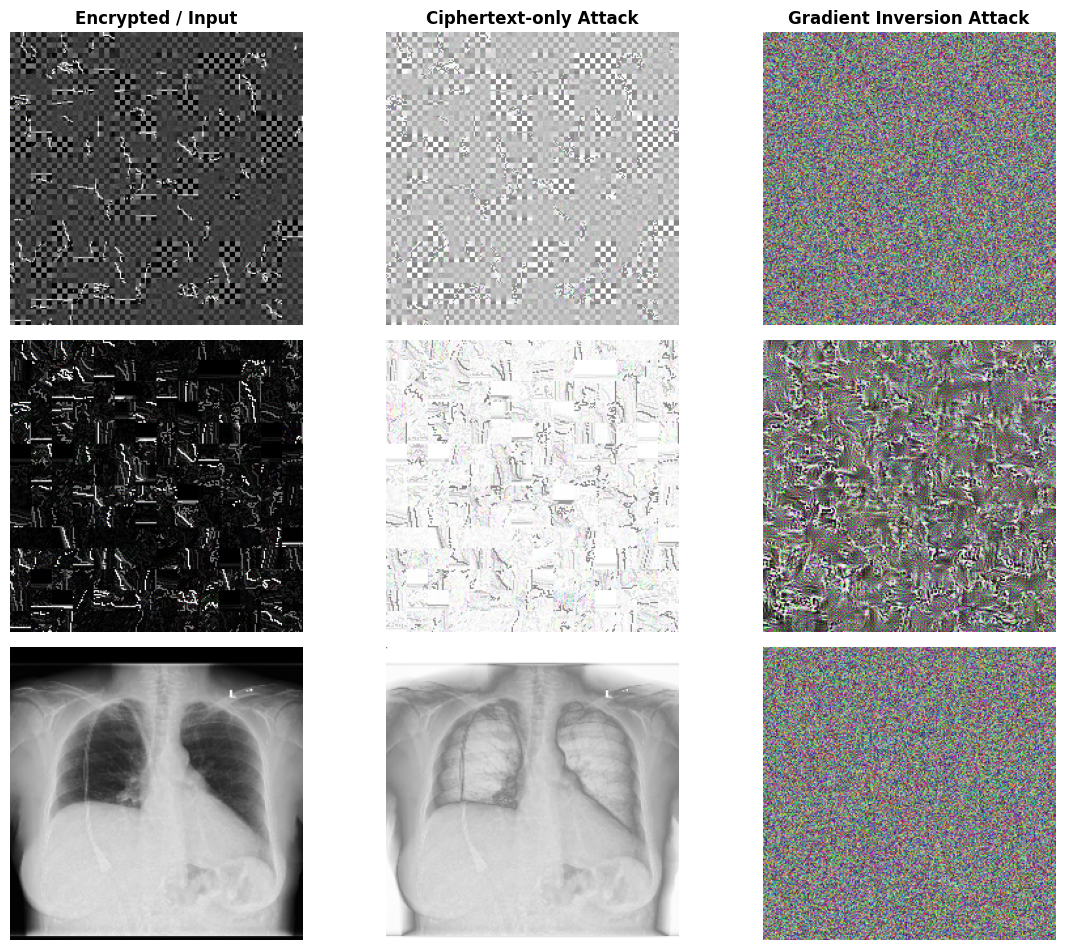

Saved figure: /content/attack_two_methods_results/attack_ablation_visual_grid.png


In [ ]:
# ============================================================
# Two Attacks on Ablation Datasets
# 1 NORMAL image per ablation
# Attacks:
#   1. Ciphertext-only Advanced Attack
#   2. Gradient Inversion Attack
# Metrics:
#   PSNR, SSIM, LPIPS
# Visualization:
#   3 columns: Encrypted/Input | Cipher | Gradient
# ============================================================

import os
import math
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim

import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.datasets import ImageFolder
from torchvision.models import resnet18, ResNet18_Weights
from tqdm.auto import tqdm


# ============================================================
# CONFIG
# ============================================================

ABLATION_ROOT = Path("/content/new_dataset_encrypted_ablationK")

OUT_ROOT = Path("/content/attack_two_methods_results")
OUT_IMG_ROOT = OUT_ROOT / "images"

OUT_DETAIL_CSV = OUT_ROOT / "attack_metrics_long.csv"
OUT_WIDE_CSV = OUT_ROOT / "attack_metrics_wide.csv"
OUT_FIG_PATH = OUT_ROOT / "attack_ablation_visual_grid.png"

IMAGE_SIZE = 224
NUM_CLASSES = 3

TARGET_CLASS = "NORMAL"

SEED = 42

# Gradient inversion config
MAX_ITERS = 800
LR = 0.1
TV_WEIGHT = 1e-4
L2_WEIGHT = 1e-6

LPIPS_NET = "alex"

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

OUT_ROOT.mkdir(parents=True, exist_ok=True)
OUT_IMG_ROOT.mkdir(parents=True, exist_ok=True)

print("Device:", DEVICE)


# ============================================================
# INSTALL / LOAD LPIPS
# ============================================================

try:
    import lpips
except ImportError:
    !pip -q install lpips
    import lpips

lpips_model = lpips.LPIPS(net=LPIPS_NET).to(DEVICE)
lpips_model.eval()


# ============================================================
# SEED
# ============================================================

def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed(SEED)


# ============================================================
# IMAGE LOAD / SAVE UTILS
# ============================================================

def load_image_array(path, image_size=224):
    img = cv2.imread(str(path))

    if img is None:
        raise FileNotFoundError(f"Cannot read image: {path}")

    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    if image_size is not None:
        img = cv2.resize(img, (image_size, image_size))

    return img.astype(np.uint8)


def load_image_tensor(path, image_size=224, device="cuda"):
    tf = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor(),
    ])

    img = Image.open(path).convert("RGB")
    x = tf(img).unsqueeze(0).to(device)

    return x


def tensor_to_pil(x):
    x = torch.clamp(x.detach().cpu(), 0, 1)
    x = x.squeeze(0).permute(1, 2, 0).numpy()
    x = (x * 255).astype(np.uint8)
    return Image.fromarray(x)


def save_tensor_image(x, save_path):
    img = tensor_to_pil(x)
    img.save(save_path)


def save_array_image(img, save_path):
    Image.fromarray(img.astype(np.uint8)).save(save_path)


# ============================================================
# METRICS: PSNR / SSIM / LPIPS
# PSNR + SSIM use skimage standard implementation
# ============================================================

def compute_psnr_np(img1, img2):
    """
    Compute PSNR using skimage.
    img1, img2: RGB uint8, HWC
    Higher PSNR means two images are more similar.
    """

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    img1 = img1.astype(np.uint8)
    img2 = img2.astype(np.uint8)

    psnr = peak_signal_noise_ratio(
        img1,
        img2,
        data_range=255
    )

    return float(psnr)


def compute_ssim_np(img1, img2):
    """
    Compute SSIM using skimage.
    img1, img2: RGB uint8, HWC
    Higher SSIM means two images are structurally more similar.
    """

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    img1 = img1.astype(np.uint8)
    img2 = img2.astype(np.uint8)

    ssim = structural_similarity(
        img1,
        img2,
        channel_axis=2,
        data_range=255
    )

    return float(ssim)


def compute_lpips_np(img1, img2):
    """
    Compute LPIPS.
    img1, img2: RGB uint8, HWC
    LPIPS input should be in [-1, 1], BCHW.
    Higher LPIPS means two images are perceptually more different.
    """

    if img1.shape != img2.shape:
        img2 = cv2.resize(img2, (img1.shape[1], img1.shape[0]))

    x = torch.from_numpy(img1.astype(np.float32) / 255.0)
    y = torch.from_numpy(img2.astype(np.float32) / 255.0)

    x = x.permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0
    y = y.permute(2, 0, 1).unsqueeze(0) * 2.0 - 1.0

    x = x.to(DEVICE)
    y = y.to(DEVICE)

    with torch.no_grad():
        score = lpips_model(x, y).item()

    return float(score)


def compute_all_metrics(img_ref, img_out):
    """
    Compare img_out against img_ref.

    For privacy leakage evaluation:
    - lower PSNR  = less pixel-level similarity to original
    - lower SSIM  = less structural similarity to original
    - higher LPIPS = more perceptual difference from original
    """

    if img_ref.shape != img_out.shape:
        img_out = cv2.resize(img_out, (img_ref.shape[1], img_ref.shape[0]))

    img_ref = img_ref.astype(np.uint8)
    img_out = img_out.astype(np.uint8)

    psnr = compute_psnr_np(img_ref, img_out)
    ssim = compute_ssim_np(img_ref, img_out)
    lpips_score = compute_lpips_np(img_ref, img_out)

    return {
        "PSNR": psnr,
        "SSIM": ssim,
        "LPIPS": lpips_score,
    }

# ============================================================
# ATTACK 1: CIPHERTEXT-ONLY ADVANCED ATTACK
# ============================================================

def check_image(img, name="img"):
    if img is None:
        raise ValueError(f"{name} is None. Make sure cv2.imread(...) loaded successfully.")

    if not isinstance(img, np.ndarray):
        raise TypeError(f"{name} must be a numpy array")

    if img.ndim != 3 or img.shape[2] != 3:
        raise ValueError(f"{name} must have shape (H, W, 3), got {img.shape}")


def generate_candidates(pixel):
    p0, p1, p2 = [int(x) for x in pixel]

    perms = np.array([
        [p0, p1, p2],
        [p0, p2, p1],
        [p1, p0, p2],
        [p1, p2, p0],
        [p2, p0, p1],
        [p2, p1, p0],
    ], dtype=np.int16)

    candidates = np.zeros((6, 8, 3), dtype=np.int16)

    for r in range(6):
        base = perms[r]

        for bf in range(8):
            b3 = bf % 2
            b2 = (bf // 2) % 2
            b1 = (bf // 4) % 2

            candidates[r, bf, 0] = base[0] if b1 == 0 else (base[0] ^ 255)
            candidates[r, bf, 1] = base[1] if b2 == 0 else (base[1] ^ 255)
            candidates[r, bf, 2] = base[2] if b3 == 0 else (base[2] ^ 255)

    return candidates


def attack_ciphertext_only_advanced(enc_img, initial_pixel=(128, 128, 128)):
    check_image(enc_img, "enc_img")

    h, w, _ = enc_img.shape

    dec = np.zeros_like(enc_img)
    dec[0, 0] = np.array(initial_pixel, dtype=np.uint8)

    for j in range(1, w):
        ref = dec[0, j - 1].astype(np.int16)
        cand = generate_candidates(enc_img[0, j])

        diff = np.abs(cand - ref).sum(axis=2)
        r, c = np.unravel_index(np.argmin(diff), diff.shape)

        dec[0, j] = cand[r, c].astype(np.uint8)

    for i in range(1, h):
        for j in range(w):
            ref = dec[i - 1, j].astype(np.int16)
            cand = generate_candidates(enc_img[i, j])

            diff = np.abs(cand - ref).sum(axis=2)
            r, c = np.unravel_index(np.argmin(diff), diff.shape)

            dec[i, j] = cand[r, c].astype(np.uint8)

    return dec


def run_cipher_attack(img_path, save_dir, file_prefix):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    input_img = load_image_array(img_path, image_size=IMAGE_SIZE)

    cipher_recovered = attack_ciphertext_only_advanced(input_img)

    input_path = save_dir / f"{file_prefix}_input.png"
    recovered_path = save_dir / f"{file_prefix}_cipher_recovered.png"
    diff_path = save_dir / f"{file_prefix}_cipher_absdiff.png"

    diff = np.abs(
        input_img.astype(np.int16)
        - cipher_recovered.astype(np.int16)
    ).astype(np.uint8)

    save_array_image(input_img, input_path)
    save_array_image(cipher_recovered, recovered_path)
    save_array_image(diff, diff_path)

    return {
        "input_path": str(input_path),
        "recovered_path": str(recovered_path),
        "diff_path": str(diff_path),
    }


# ============================================================
# ATTACK 2: GRADIENT INVERSION ATTACK
# ============================================================

def total_variation(x):
    dh = torch.mean(torch.abs(x[:, :, 1:, :] - x[:, :, :-1, :]))
    dw = torch.mean(torch.abs(x[:, :, :, 1:] - x[:, :, :, :-1]))
    return dh + dw


def gradient_cosine_loss(dummy_grads, target_grads):
    num = 0.0
    den1 = 0.0
    den2 = 0.0

    for dg, tg in zip(dummy_grads, target_grads):
        num = num + (dg * tg).sum()
        den1 = den1 + (dg * dg).sum()
        den2 = den2 + (tg * tg).sum()

    return 1 - num / (torch.sqrt(den1) * torch.sqrt(den2) + 1e-12)


def compute_mse_tensor(img1, img2):
    img1 = torch.clamp(img1, 0, 1)
    img2 = torch.clamp(img2, 0, 1)

    return torch.mean((img1 - img2) ** 2).item()


def compute_psnr_tensor(img1, img2):
    mse = compute_mse_tensor(img1, img2)

    if mse == 0:
        return float("inf")

    return 10.0 * math.log10(1.0 / mse)


def build_attack_model(num_classes=3):
    weights = ResNet18_Weights.DEFAULT

    model = resnet18(weights=weights)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)

    model = model.to(DEVICE)
    model.eval()

    return model


# Build one fixed attack model for fairness
set_seed(SEED)
ATTACK_MODEL = build_attack_model(num_classes=NUM_CLASSES)


def run_gradient_inversion_attack(
    img_path,
    label,
    save_dir,
    file_prefix,
    max_iters=800,
    lr=0.1,
    tv_weight=1e-4,
    l2_weight=1e-6
):
    save_dir = Path(save_dir)
    save_dir.mkdir(parents=True, exist_ok=True)

    gt_data = load_image_tensor(
        img_path,
        image_size=IMAGE_SIZE,
        device=DEVICE
    )

    gt_label = torch.tensor(
        [label],
        dtype=torch.long,
        device=DEVICE
    )

    model = ATTACK_MODEL
    criterion = nn.CrossEntropyLoss()

    model.zero_grad(set_to_none=True)

    out = model(gt_data)
    target_loss = criterion(out, gt_label)

    target_grads = torch.autograd.grad(
        target_loss,
        model.parameters()
    )

    target_grads = [
        g.detach().clone()
        for g in target_grads
    ]

    dummy_data = torch.randn_like(
        gt_data,
        device=DEVICE,
        requires_grad=True
    )

    optimizer = optim.Adam(
        [dummy_data],
        lr=lr
    )

    scheduler = optim.lr_scheduler.MultiStepLR(
        optimizer,
        milestones=[
            max_iters // 2,
            int(max_iters * 0.75)
        ],
        gamma=0.3
    )

    best_psnr = -1e9
    best_dummy = None
    best_iter = -1
    best_loss = None

    for it in range(1, max_iters + 1):
        optimizer.zero_grad(set_to_none=True)

        dummy_clamped = torch.sigmoid(dummy_data)

        pred = model(dummy_clamped)
        dummy_loss_ce = criterion(pred, gt_label)

        dummy_grads = torch.autograd.grad(
            dummy_loss_ce,
            model.parameters(),
            create_graph=True
        )

        grad_loss = gradient_cosine_loss(
            dummy_grads,
            target_grads
        )

        tv_loss = total_variation(dummy_clamped)
        l2_loss = torch.mean(dummy_clamped ** 2)

        total_loss = (
            grad_loss
            + tv_weight * tv_loss
            + l2_weight * l2_loss
        )

        total_loss.backward()
        optimizer.step()
        scheduler.step()

        with torch.no_grad():
            current_dummy = torch.sigmoid(dummy_data)
            current_psnr = compute_psnr_tensor(gt_data, current_dummy)

            if current_psnr > best_psnr:
                best_psnr = current_psnr
                best_dummy = current_dummy.detach().clone()
                best_iter = it
                best_loss = total_loss.item()

    recovered_path = save_dir / f"{file_prefix}_gradient_recovered.png"
    diff_path = save_dir / f"{file_prefix}_gradient_absdiff.png"

    final_dummy = best_dummy

    abs_diff = torch.abs(
        torch.clamp(gt_data, 0, 1)
        - torch.clamp(final_dummy, 0, 1)
    )

    save_tensor_image(final_dummy, recovered_path)
    save_tensor_image(
        abs_diff / (abs_diff.max() + 1e-8),
        diff_path
    )

    final_mse = compute_mse_tensor(gt_data, final_dummy)
    final_psnr = compute_psnr_tensor(gt_data, final_dummy)

    return {
        "best_iter": best_iter,
        "best_loss": best_loss,
        "attack_mse": final_mse,
        "attack_psnr": final_psnr,
        "recovered_path": str(recovered_path),
        "diff_path": str(diff_path),
    }


# ============================================================
# SELECT 1 NORMAL SAMPLE
# ============================================================

def get_ablation_folders(root):
    folders = [
        p for p in Path(root).iterdir()
        if p.is_dir()
    ]

    return sorted(folders, key=lambda x: x.name)


def choose_one_normal_sample(ablation_root, target_class="NORMAL"):
    base_root = Path(ablation_root) / "k_1"

    ds = ImageFolder(str(base_root))

    if target_class not in ds.class_to_idx:
        raise ValueError(
            f"Cannot find class {target_class}. "
            f"Available classes: {ds.classes}"
        )

    target_label = ds.class_to_idx[target_class]

    for path, label in ds.samples:
        if label == target_label:
            rel_path = Path(path).relative_to(base_root)

            sample = {
                "rel_path": str(rel_path),
                "label": int(label),
                "class_name": target_class,
            }

            print("Selected sample:", sample)
            print("Classes:", ds.classes)
            print("class_to_idx:", ds.class_to_idx)

            return sample, ds.classes, ds.class_to_idx

    raise RuntimeError(f"No image found for class {target_class}")


# ============================================================
# PLOT GRID: 3 COLUMNS
# ============================================================

def plot_attack_grid(rows, save_path):
    """
    3 image columns:
    Encrypted/Input | Cipher Attack | Gradient Attack

    Ablation name is shown on the left as y-label.
    """

    df = pd.DataFrame(rows)

    ablations = df["ablation"].tolist()
    n = len(ablations)

    fig, axes = plt.subplots(
        nrows=n,
        ncols=3,
        figsize=(12, 3.2 * n)
    )

    if n == 1:
        axes = np.expand_dims(axes, axis=0)

    col_titles = [
        "Encrypted / Input",
        "Ciphertext-only Attack",
        "Gradient Inversion Attack"
    ]

    for j, title in enumerate(col_titles):
        axes[0, j].set_title(title, fontsize=12, fontweight="bold")

    for i, row in df.iterrows():
        input_img = load_image_array(row["input_path"], image_size=IMAGE_SIZE)
        cipher_img = load_image_array(row["cipher_recovered_path"], image_size=IMAGE_SIZE)
        grad_img = load_image_array(row["gradient_recovered_path"], image_size=IMAGE_SIZE)

        imgs = [input_img, cipher_img, grad_img]

        for j in range(3):
            axes[i, j].imshow(imgs[j])
            axes[i, j].axis("off")

        axes[i, 0].set_ylabel(
            row["ablation"],
            fontsize=11,
            rotation=0,
            labelpad=60,
            va="center",
            fontweight="bold"
        )

    plt.tight_layout()
    plt.savefig(save_path, dpi=200, bbox_inches="tight")
    plt.show()

    print("Saved figure:", save_path)


# ============================================================
# RUN ALL
# ============================================================

def run_two_attacks_all_ablations():
    sample, classes, class_to_idx = choose_one_normal_sample(
        ABLATION_ROOT,
        target_class=TARGET_CLASS
    )

    ablation_folders = get_ablation_folders(ABLATION_ROOT)

    rows_for_plot = []
    metric_rows = []

    rel_path = sample["rel_path"]
    label = sample["label"]
    class_name = sample["class_name"]

    original_path = ABLATION_ROOT / "original" / rel_path
    original_img = load_image_array(original_path, image_size=IMAGE_SIZE)

    for ablation_dir in tqdm(ablation_folders, desc="Ablations"):
        ablation_name = ablation_dir.name

        img_path = ablation_dir / rel_path

        if not img_path.exists():
            print("Missing:", img_path)
            continue

        safe_stem = (
            Path(rel_path)
            .with_suffix("")
            .as_posix()
            .replace("/", "_")
        )

        file_prefix = f"{ablation_name}_{safe_stem}"
        save_dir = OUT_IMG_ROOT / ablation_name

        save_dir.mkdir(parents=True, exist_ok=True)

        # -------------------------
        # Save input/encrypted image
        # -------------------------
        input_img = load_image_array(img_path, image_size=IMAGE_SIZE)
        input_path_saved = save_dir / f"{file_prefix}_encrypted_input.png"
        save_array_image(input_img, input_path_saved)

        # -------------------------
        # Attack 1: Ciphertext-only
        # -------------------------
        cipher_result = run_cipher_attack(
            img_path=img_path,
            save_dir=save_dir,
            file_prefix=file_prefix
        )

        # -------------------------
        # Attack 2: Gradient inversion
        # -------------------------
        gradient_result = run_gradient_inversion_attack(
            img_path=img_path,
            label=label,
            save_dir=save_dir,
            file_prefix=file_prefix,
            max_iters=MAX_ITERS,
            lr=LR,
            tv_weight=TV_WEIGHT,
            l2_weight=L2_WEIGHT
        )

        # -------------------------
        # Load recovered images
        # -------------------------
        cipher_img = load_image_array(
            cipher_result["recovered_path"],
            image_size=IMAGE_SIZE
        )

        gradient_img = load_image_array(
            gradient_result["recovered_path"],
            image_size=IMAGE_SIZE
        )

        # -------------------------
        # Metrics vs original image
        # Đây là privacy leakage evaluation.
        # PSNR/SSIM thấp, LPIPS cao => ít giống ảnh gốc hơn.
        # -------------------------
        input_metrics = compute_all_metrics(
            original_img,
            input_img
        )

        cipher_metrics = compute_all_metrics(
            original_img,
            cipher_img
        )

        gradient_metrics = compute_all_metrics(
            original_img,
            gradient_img
        )

        metric_rows.append({
            "ablation": ablation_name,
            "attack": "encrypted_input",
            "PSNR": input_metrics["PSNR"],
            "SSIM": input_metrics["SSIM"],
            "LPIPS": input_metrics["LPIPS"],
        })

        metric_rows.append({
            "ablation": ablation_name,
            "attack": "ciphertext_only_advanced",
            "PSNR": cipher_metrics["PSNR"],
            "SSIM": cipher_metrics["SSIM"],
            "LPIPS": cipher_metrics["LPIPS"],
        })

        metric_rows.append({
            "ablation": ablation_name,
            "attack": "gradient_inversion",
            "PSNR": gradient_metrics["PSNR"],
            "SSIM": gradient_metrics["SSIM"],
            "LPIPS": gradient_metrics["LPIPS"],
        })

        rows_for_plot.append({
            "ablation": ablation_name,
            "input_path": str(input_path_saved),
            "cipher_recovered_path": cipher_result["recovered_path"],
            "gradient_recovered_path": gradient_result["recovered_path"],
        })

        pd.DataFrame(metric_rows).to_csv(OUT_DETAIL_CSV, index=False)

    # -------------------------
    # Save long metric CSV
    # columns: ablation, attack, PSNR, SSIM, LPIPS
    # -------------------------
    df_long = pd.DataFrame(metric_rows)
    df_long.to_csv(OUT_DETAIL_CSV, index=False)

    # -------------------------
    # Save wide metric CSV
    # columns:
    # ablation,
    # encrypted_input_PSNR, encrypted_input_SSIM, encrypted_input_LPIPS,
    # cipher_PSNR, cipher_SSIM, cipher_LPIPS,
    # gradient_PSNR, gradient_SSIM, gradient_LPIPS
    # -------------------------
    df_wide = df_long.pivot(
        index="ablation",
        columns="attack",
        values=["PSNR", "SSIM", "LPIPS"]
    )

    df_wide.columns = [
        f"{attack}_{metric}"
        for metric, attack in df_wide.columns
    ]

    df_wide = df_wide.reset_index()
    df_wide.to_csv(OUT_WIDE_CSV, index=False)

    print("Saved detail CSV:", OUT_DETAIL_CSV)
    print("Saved wide CSV:", OUT_WIDE_CSV)

    display(df_long)
    display(df_wide)

    # -------------------------
    # Plot 3-column visual grid
    # -------------------------
    plot_attack_grid(
        rows_for_plot,
        save_path=OUT_FIG_PATH
    )

    return df_long, df_wide


df_attack_long, df_attack_wide = run_two_attacks_all_ablations()

In [ ]:
import pandas as pd
from IPython.display import display

df_long = pd.read_csv("/content/attack_two_methods_results/attack_metrics_long.csv")
df_wide = pd.read_csv("/content/attack_two_methods_results/attack_metrics_wide.csv")

display(df_long)
display(df_wide)

,ablation,attack,PSNR,SSIM,LPIPS
0,A0_original,encrypted_input,inf,1.000000,0.000000
1,A0_original,ciphertext_only_advanced,8.095549,0.613798,0.301207
2,A0_original,gradient_inversion,8.964373,0.021264,1.384404
3,A1_msb_lsb_only,encrypted_input,5.253494,0.221478,0.705930
4,A1_msb_lsb_only,ciphertext_only_advanced,6.495956,0.281208,0.714407
5,A1_msb_lsb_only,gradient_inversion,8.955368,0.021096,1.408469
6,A2_msb_lsb_block_xor,encrypted_input,5.177439,0.109892,0.733576
7,A2_msb_lsb_block_xor,ciphertext_only_advanced,6.673449,0.304863,0.776662
8,A2_msb_lsb_block_xor,gradient_inversion,8.460465,0.018129,1.201767
9,A3_random_shuffle,encrypted_input,5.184632,0.078385,0.803350


,ablation,ciphertext_only_advanced_PSNR,encrypted_input_PSNR,gradient_inversion_PSNR,ciphertext_only_advanced_SSIM,encrypted_input_SSIM,gradient_inversion_SSIM,ciphertext_only_advanced_LPIPS,encrypted_input_LPIPS,gradient_inversion_LPIPS
0,A0_original,8.095549,inf,8.964373,0.613798,1.000000,0.021264,0.301207,0.000000,1.384404
1,A1_msb_lsb_only,6.495956,5.253494,8.955368,0.281208,0.221478,0.021096,0.714407,0.705930,1.408469
2,A2_msb_lsb_block_xor,6.673449,5.177439,8.460465,0.304863,0.109892,0.018129,0.776662,0.733576,1.201767
3,A3_random_shuffle,6.664500,5.184632,8.517975,0.269532,0.078385,0.019588,0.815437,0.803350,1.154796
4,A4_chaos_shuffle,6.639950,5.224967,8.304920,0.265912,0.077494,0.017966,0.811195,0.793084,1.136560
5,A5_dct_only,6.677567,5.172202,8.607617,0.270637,0.095569,0.019801,0.853212,0.734164,1.214919
6,A6_full_proposed,6.635341,5.223175,8.325151,0.236246,0.068542,0.018141,0.880487,0.794769,1.174796
